In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gymnasium as gym


import matplotlib.pyplot as plt
import torch
from tensorboard.backend.event_processing import event_accumulator
from pathlib import Path
from stable_baselines3 import DQN as SB3DQN

from highway.scripts.environment import get_env, ConfigType
from highway.scripts.run import eval_agent, run_one_episode
from highway.scripts.utils.agents import SB3GreedyAgent
from highway.scripts.utils.paths import get_training_paths
from highway.scripts.utils.plotting import (
    plot_losses,
    plot_rewards_lengths,
    plot_train_rewards_lengths,
)
from highway.scripts.utils.statistics import compute_confidence_interval
from highway.scripts.utils.save_gif import save_gif
from copy import deepcopy

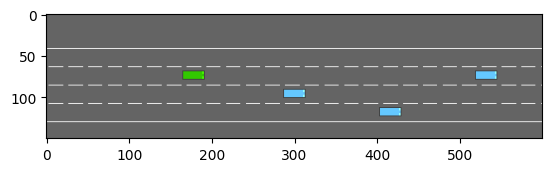

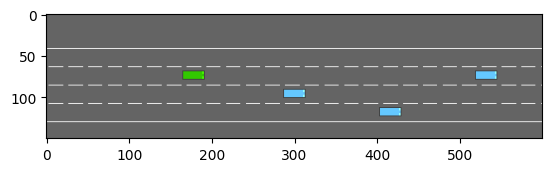

In [3]:
env = get_env(seed=1, config_type=ConfigType.SHARED_CORE)
env_CNN = get_env(seed=1, config_type=ConfigType.TEST_CNN)
# Show the environment
plt.imshow(env.render())
plt.show()
plt.imshow(env_CNN.render())
plt.show()

## Evaluation setup

In [4]:
eval_seeds = list(range(50))

## Baseline

### Random Agent

In [5]:
from highway.models.random_agent.random_agent import RandomAgent

agent = RandomAgent(env.observation_space, env.action_space)

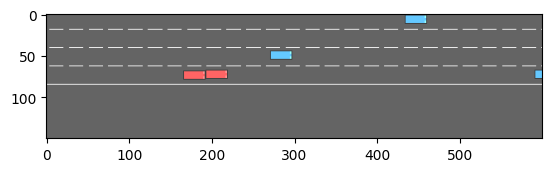

Episode reward=3.40, length=5


In [6]:
should_save = True

seed = 4
reward, length = run_one_episode(env, agent, display=True, seed=seed)

if should_save:
    save_gif(env, agent, path="random_agent.gif", seed=seed)

In [7]:
rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 50/50 [01:54<00:00,  2.28s/ep]


In [8]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 10.23 ± 2.05 (95% CI: [8.19, 12.28])
Length: 13.54 ± 2.63 (95% CI: [10.91, 16.17])


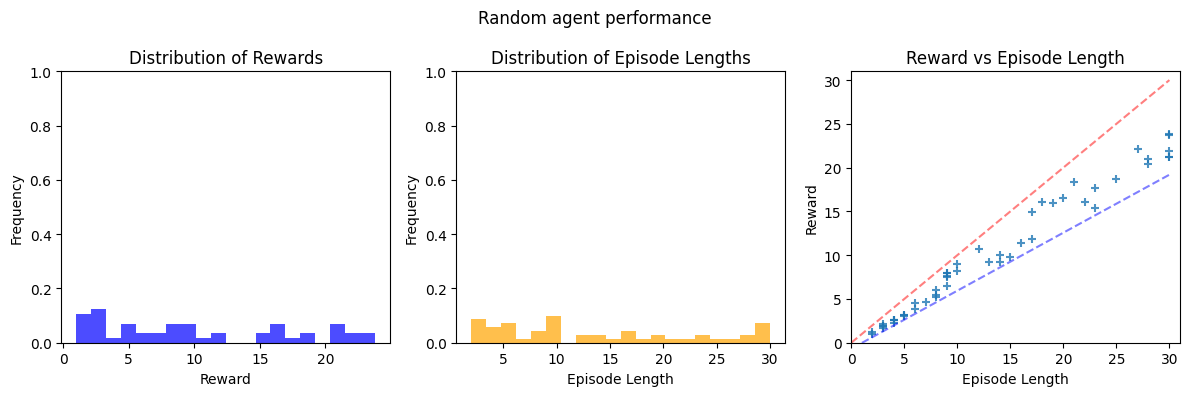

In [9]:
plot_rewards_lengths(rewards, lengths, title="Random agent performance")

### Idle agent

In [10]:
from highway.models.idle_agent.idle_agent import IdleAgent

agent = IdleAgent(env.observation_space, env.action_space)

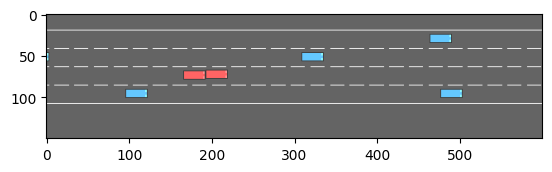

Episode reward=21.68, length=28


In [11]:
should_save = True

seed = 4
reward, length = run_one_episode(env, agent, display=True, seed=seed)

if should_save:
    save_gif(env, agent, path="idle_agent.gif", seed=seed)

In [12]:
rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 50/50 [02:49<00:00,  3.39s/ep]


In [13]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 14.59 ± 2.02 (95% CI: [12.57, 16.61])
Length: 19.02 ± 2.45 (95% CI: [16.57, 21.47])


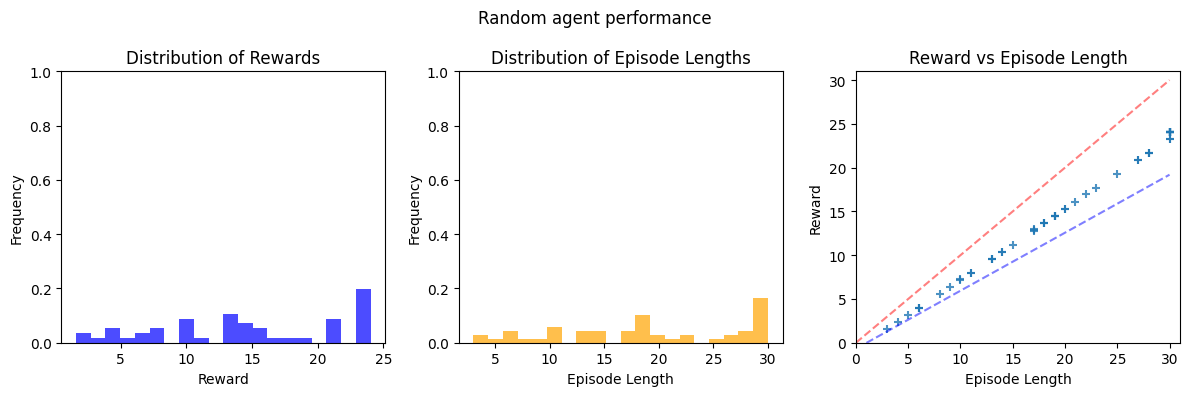

In [14]:
plot_rewards_lengths(rewards, lengths, title="Random agent performance")

## DQN Agent

In [15]:
from highway.models.dqn.dqn import DQN

action_space = env.action_space
observation_space = env.observation_space

gamma = 0.9
batch_size = 64
buffer_capacity = 10_000
update_target_every = 200

epsilon_start = 0.95
decrease_epsilon_factor = 50
epsilon_min = 0.05

learning_rate = 5e-4

arguments = (action_space,
            observation_space,
            gamma,
            batch_size,
            buffer_capacity,
            update_target_every, 
            epsilon_start, 
            decrease_epsilon_factor, 
            epsilon_min,
            learning_rate,
        )

dqn_base_agent = DQN(*arguments)

### Identical environment for training and evaluation

In [16]:
date_str = "20260410_152850"

best_model_path, losses, train_rewards, train_lengths, ep_paths = get_training_paths(date_str)

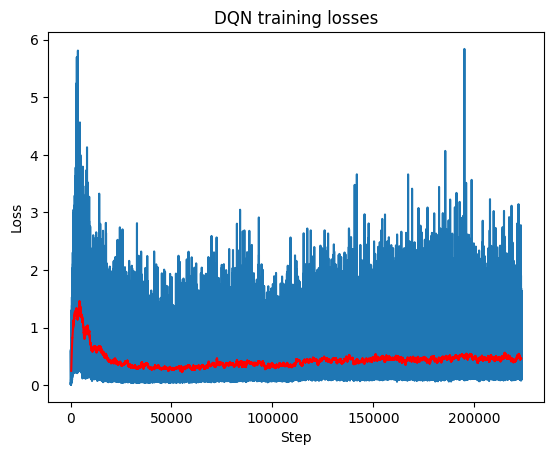

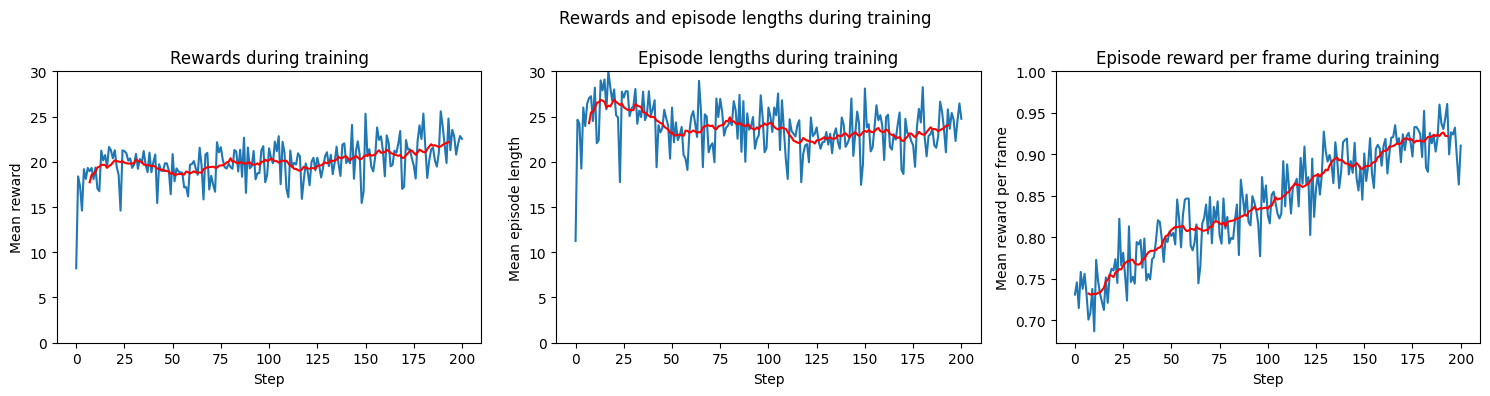

In [17]:
plot_losses(losses, nb_smoothen=500, title="DQN training losses")
plot_train_rewards_lengths(train_rewards, train_lengths, nb_smoothen=15)

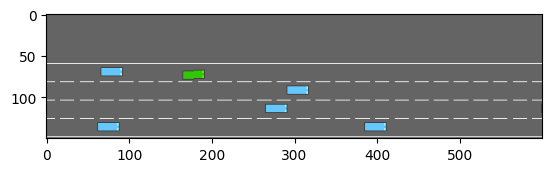

Episode reward=27.04, length=30


In [18]:
should_save = True
seed = 4

agent = deepcopy(dqn_base_agent)
agent.q_net.load_state_dict(torch.load(best_model_path))

reward, length = run_one_episode(env, agent, display=True, seed=seed)

if should_save:
    save_gif(env, agent, path="manual_dqn_mlp_agent.gif", seed=seed)

In [19]:
rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 50/50 [03:28<00:00,  4.17s/ep]


In [20]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 21.09 ± 2.34 (95% CI: [18.75, 23.43])
Length: 23.04 ± 2.43 (95% CI: [20.61, 25.47])


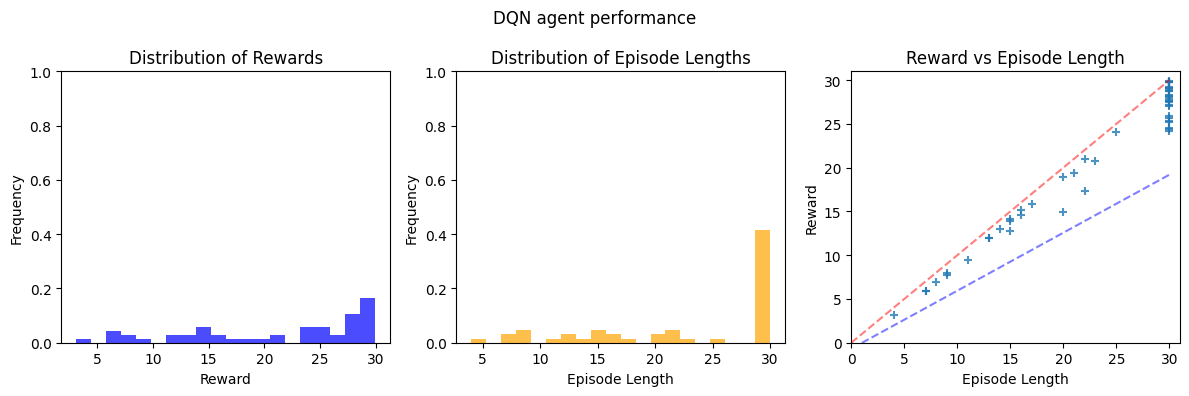

In [21]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")

# DQN (Stable Baselines) 

Less training steps because of the long training time. But the behavior is the same as the one we implemented ourselves.

In [5]:
from highway.models.dqn_sb3.dqn_sb3 import DQN_SB3
import pandas as pd
import os 

best_model_path = os.path.join("logs", "dqn_sb3", "best_model", "best_model.zip")

dqn_sb3_agent = DQN_SB3.load(best_model_path, env=env)

dqn_progress = pd.read_csv(os.path.join("logs", "dqn_sb3", "progress.csv"))
dqn_train_monitor = pd.read_csv(os.path.join("logs", "dqn_sb3", "train_monitor.csv"), comment="#")

losses = dqn_progress["train/loss"].fillna(0).values
rewards = dqn_train_monitor["r"].fillna(0).values
lengths = dqn_train_monitor["l"].fillna(0).values

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


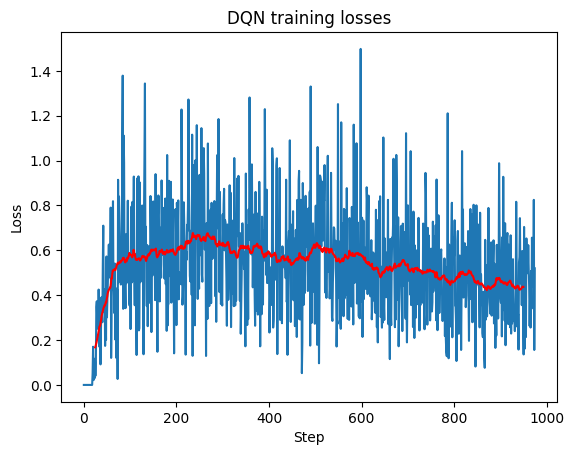

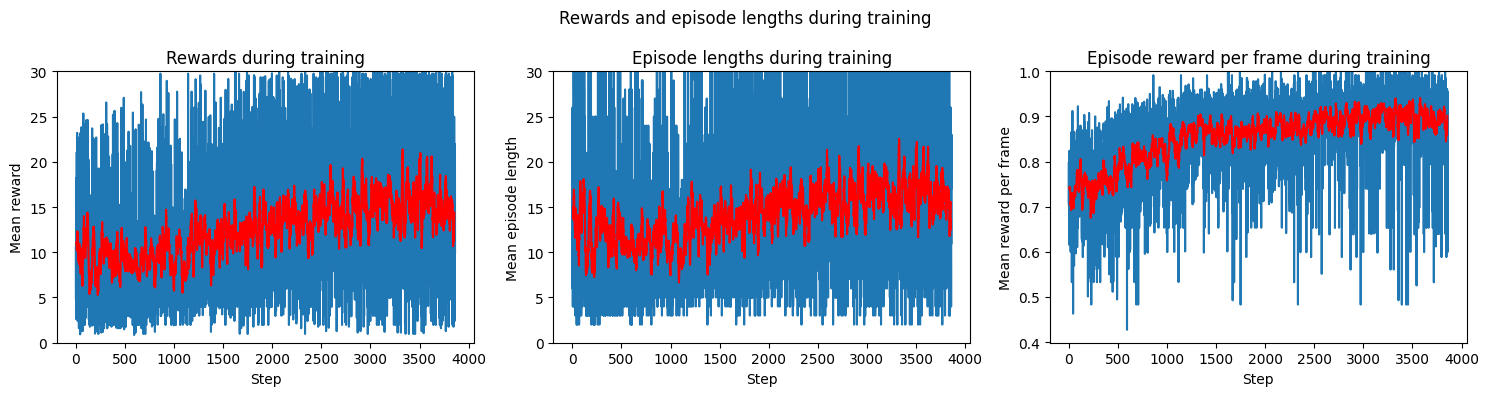

In [6]:
plot_losses(losses, nb_smoothen=50, title="DQN training losses")
plot_train_rewards_lengths(rewards, lengths, nb_smoothen=15)

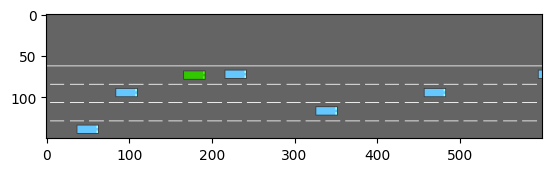

Episode reward=29.78, length=30


In [7]:
reward, length = run_one_episode(env, dqn_sb3_agent, display=True)

In [8]:
rewards, lengths = eval_agent(env, dqn_sb3_agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 50/50 [02:12<00:00,  2.66s/ep]


In [9]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 15.21 ± 1.93 (95% CI: [13.28, 17.13])
Length: 16.22 ± 1.89 (95% CI: [14.33, 18.11])


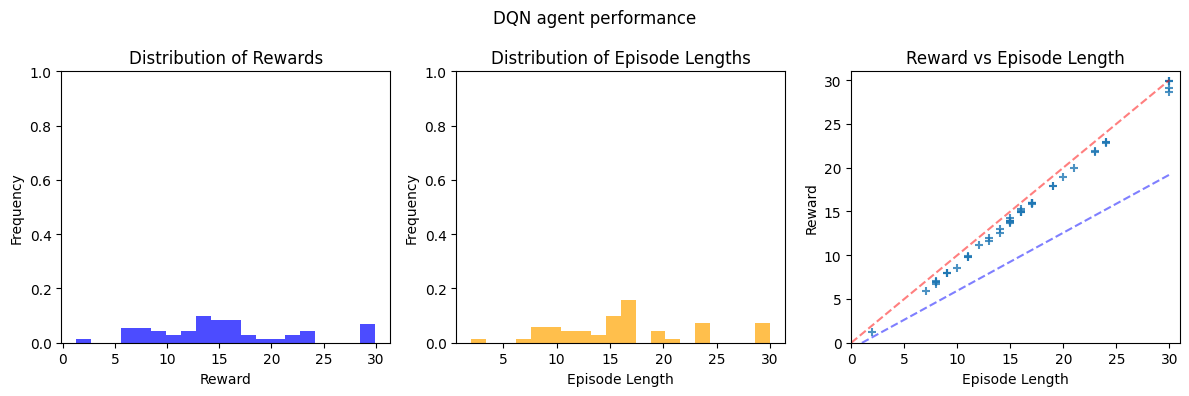

In [10]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")